In [23]:
from matplotlib import pyplot as plt
import numpy as np
from data import data
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.signal import savgol_filter

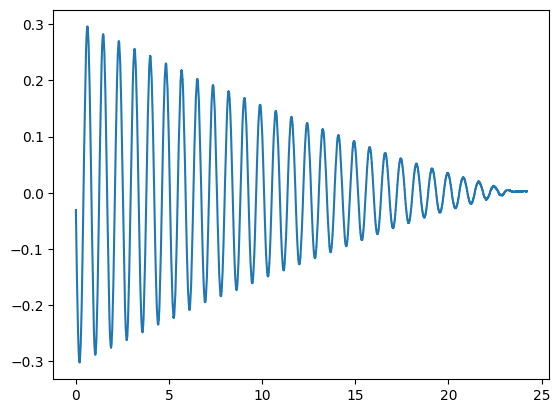

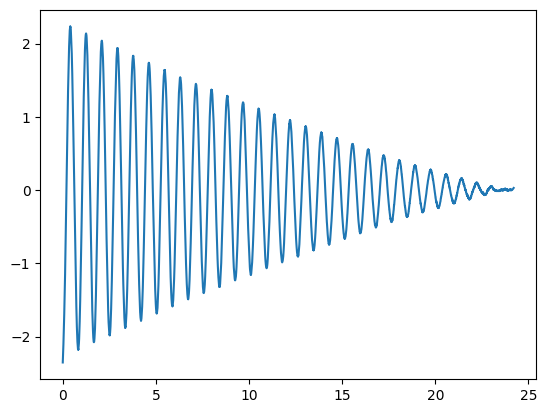

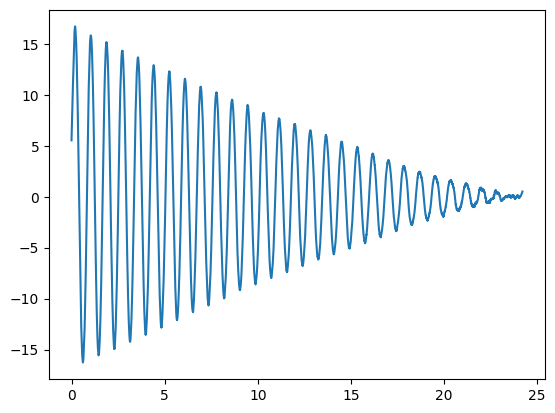

In [76]:
time, theta = list(zip(*data[20000:]))

time = np.array(time)-time[0]
plt.plot(time, theta)
plt.show()
theta_dot = savgol_filter(np.gradient(theta, time), 100, 2)
plt.plot(time, theta_dot)
plt.show()
theta_ddot = savgol_filter(np.gradient(theta_dot, time), 80, 2)
plt.plot(time, theta_ddot)
plt.show()

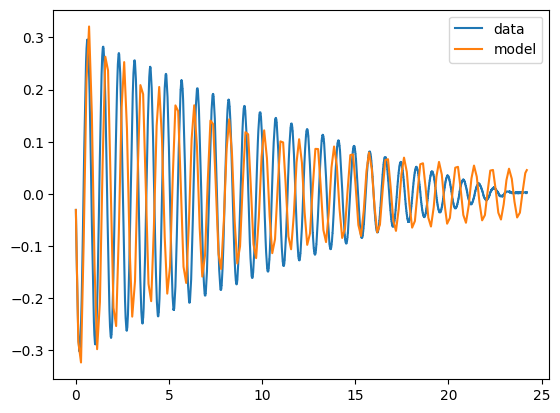

In [75]:
def norm(th):
    th = np.mod(th, 2*np.pi)
    th = np.where(th > np.pi, th - 2*np.pi, th)
    return th

g = 9.81

m_bob = 10e-3#32e-3 - 10e-3
m_shaft = 48e-3
m_rod = 27e-3#30e-3

r_shaft = 8e-3/2
len = 200e-3 # 320e-3
c1 = 1e-4

def pendulum(t, y, params):
    """returns the full nonlinear state space derivative"""
    m_bob, m_shaft, m_rod, r_shaft, len, c1, c2 = params
    th, th_dot = y
    x_dot = 0
    x_ddot = 0
    c = c1 + c2*np.abs(th_dot)

    denom = 12*len**2*m_bob + 7*len**2*m_rod + 6*m_shaft*r_shaft**2
    th_ddot = -(12*c*th_dot + 12*g*len*m_bob*np.sin(th) + 6*g*len*m_rod*np.sin(th) + 12*len*m_bob*np.cos(th)*x_ddot + 6*len*m_rod*np.cos(th)*x_ddot)/denom 
    return np.array([th_dot, th_ddot])

y0 = [theta[0], theta_dot[0]]
t_span = (time[0], time[-1])
 
def residuals(params):
    return np.linalg.norm([pendulum(0, [th, th_d], params)[1]-th_dd for th, th_d, th_dd in zip(theta, theta_dot, theta_ddot)]) 

p0 = [m_bob, m_shaft, m_rod, r_shaft, len, c1, c2]

out = solve_ivp(pendulum, t_span, y0, args=[p0])
plt.plot(time, theta, label='data')
plt.plot(out.t, norm(out.y[0]), label='model')
plt.legend()

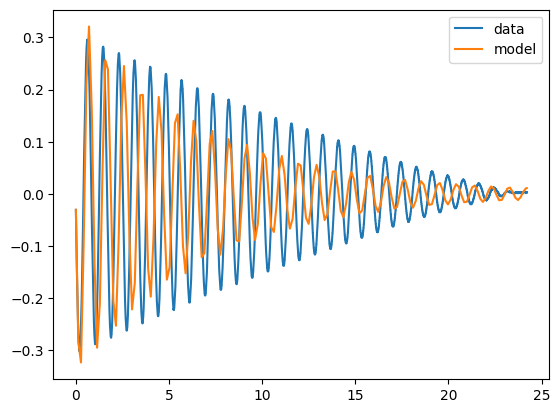

In [67]:
cost = lambda p_in: residuals([m_bob, m_shaft, m_rod, r_shaft, len, p_in[0], p_in[1], p_in[2]])

c1_opt, c2_opt, c3_opt  = minimize(cost, [0, c2, c3]).x

m_b = abs(m_b)
m_s = abs(m_s)
m_r = abs(m_r)

p0 = [m_bob, m_shaft, m_rod, r_shaft, len, c1_opt, c2_opt, c3_opt]
out = solve_ivp(pendulum, t_span, y0, args=[p0])

plt.plot(time, theta, label='data')
plt.plot(out.t, norm(out.y[0]), label='model')
plt.legend()
plt.show()

In [59]:
print(f'Initial Cost {residuals([m_bob, m_shaft, m_rod, r_shaft, len, c1, c2, c3]):.3f}')
print(f'Optimized Cost {residuals([m_b, m_s, m_r, r_shaft, len, c1_opt, c2_opt, c3_opt]):.3f}')



print(f'bob mass = {m_b:.2g}')
print(f'shaft mass = {m_s:.2g}')
print(f'rod mass = {m_r:.2g}')

print(f'c1 = {c1_opt:.2g}')
print(f'c2 = {c2_opt:.2g}')
print(f'c3 = {c3_opt:.2g}')


Initial Cost 629.506
Optimized Cost 383.568
bob mass = 0.025
shaft mass = 0.011
rod mass = 7.4e-10
c1 = 0.00018
c2 = 7.9e-05
c3 = 0.0019
